In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from os import listdir
from IPython.display import display

In [2]:
root = Path.cwd().parent.parent
figures = root / 'results' / '02_figures'

In [3]:

RUN = root / 'outputs' / listdir(root / 'outputs')[0]
runs = sorted((root / 'outputs').glob('*/training_history.csv'), key=lambda p: p.stat().st_mtime)
run = Path(RUN) if RUN else runs[-1].parent
h = pd.read_csv(run / 'training_history.csv').sort_values('global_epoch')
x = h.global_epoch

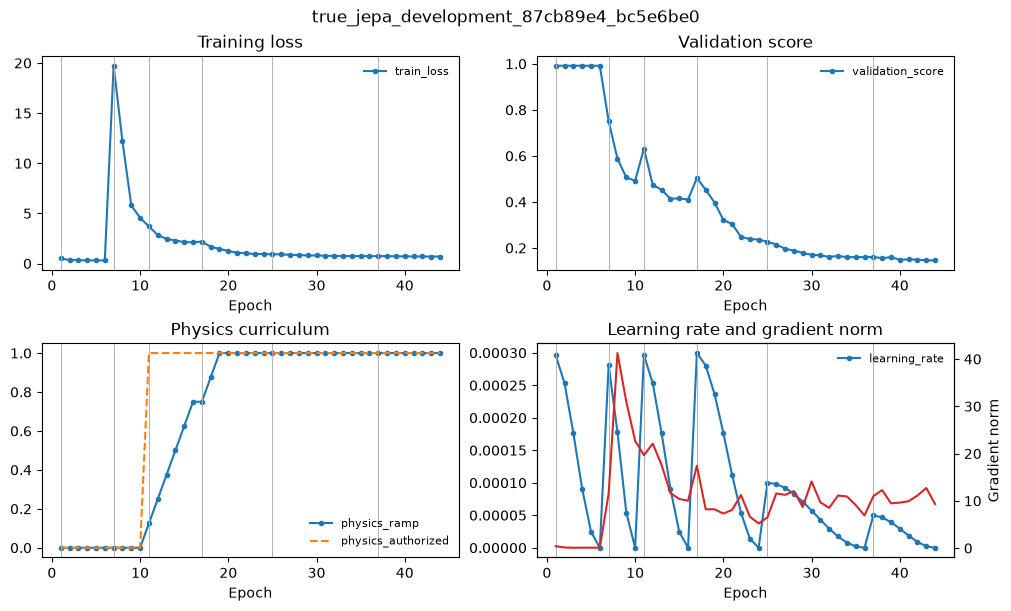

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
for ax, col, title in zip(axes.flat, ['train_loss', 'validation_score', 'physics_ramp', 'learning_rate'], ['Training loss', 'Validation score', 'Physics curriculum', 'Learning rate and gradient norm']):
    ax.plot(x, h[col], '-o', ms=3, label=col)
    for stage, part in h.groupby('stage', sort=False): ax.axvline(part.global_epoch.iloc[0], color='0.7', lw=.7)
    ax.set(xlabel='Epoch', title=title); ax.legend(frameon=False, fontsize=8)
if 'physics_authorized' in h: axes[1, 0].plot(x, h.physics_authorized.astype(int), '--', label='physics_authorized'); axes[1, 0].legend(frameon=False, fontsize=8)
ax2 = axes[1, 1].twinx(); ax2.plot(x, h.gradient_norm_post_clip, color='tab:red', label='gradient norm'); ax2.set_ylabel('Gradient norm')
fig.suptitle(run.name)
fig.savefig(figures / f'curriculum_dashboard_{run.name}.{'jpg'}', dpi=600)
plt.show()

In [5]:
g = pd.read_csv(run / 'generalization_summary.csv')
display(g.nlargest(5, 'fidelity_mean')[['category', 'fidelity_mean']], g.nsmallest(5, 'fidelity_mean')[['category', 'fidelity_mean']])

,category,fidelity_mean
20,within_range_unseen_parameter_interpolation,0.995100
1,anharmonic_wells,0.995004
13,nonuniform_resolution,0.993394
19,variable_uniform_resolution,0.992024
11,multiwell_potentials,0.991904


,category,fidelity_mean
12,near_continuum_states,0.584869
17,unseen_analytical_functional_forms,0.684158
18,valid_spatial_reflection,0.789356
5,constant_potential_shift,0.797265
6,controlled_smooth_perturbations,0.809846
